In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import os
import cv2
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from PIL import Image

from skimage.feature import hog

import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict
)

print("Libraries Loaded Successfully")

2026-06-18 08:03:23.265659: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781769803.534266      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781769803.608935      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781769804.204065      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781769804.204183      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781769804.204191      16 computation_placer.cc:177] computation placer alr

Libraries Loaded Successfully


In [3]:
train_path = "/kaggle/input/datasets/dollyprajapati182/balanced-raf-db-dataset-7575-grayscale/train"

In [4]:
emotion_map = {

    'angry':0,
    'disgust':1,
    'fear':2,
    'happy':3,
    'neutral':4,
    'sad':5,
    'surprise':6
}

emotion_names = [

    'Angry',
    'Disgust',
    'Fear',
    'Happy',
    'Neutral',
    'Sad',
    'Surprise'
]

In [5]:
data = []
labels = []

max_images_per_class = 500

for emotion_folder in os.listdir(train_path):

    folder_path = os.path.join(
        train_path,
        emotion_folder
    )

    if not os.path.isdir(folder_path):
        continue

    if emotion_folder not in emotion_map:
        continue

    label = emotion_map[emotion_folder]

    image_list = os.listdir(folder_path)

    selected_images = random.sample(
        image_list,
        min(max_images_per_class,
            len(image_list))
    )

    for img_name in tqdm(
        selected_images,
        desc=emotion_folder
    ):

        img_path = os.path.join(
            folder_path,
            img_name
        )

        try:

            img = cv2.imread(
                img_path,
                cv2.IMREAD_GRAYSCALE
            )

            if img is None:
                continue

            img = cv2.resize(
                img,
                (128,128)
            )

            data.append(img)

            labels.append(label)

        except:
            pass

data = np.array(data)
labels = np.array(labels)

print("Data Shape :", data.shape)
print("Labels Shape :", labels.shape)

happy: 100%|██████████| 500/500 [00:01<00:00, 256.00it/s]


Data Shape : (3500, 128, 128)
Labels Shape : (3500,)


In [6]:
print("Total Images :", len(data))

print("Total Classes :", len(emotion_names))

for i, emotion in enumerate(emotion_names):

    print(
        f"{emotion}: {(labels==i).sum()}"
    )

Total Images : 3500
Total Classes : 7
Angry: 500
Disgust: 500
Fear: 500
Happy: 500
Neutral: 500
Sad: 500
Surprise: 500


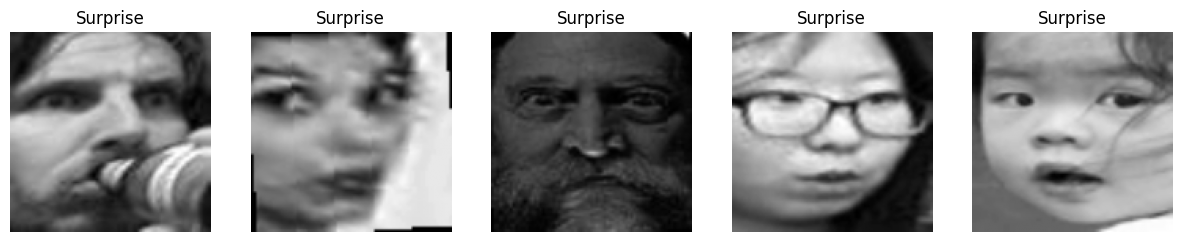

In [7]:
plt.figure(figsize=(15,5))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(
        data[i],
        cmap='gray'
    )

    plt.title(
        emotion_names[labels[i]]
    )

    plt.axis('off')

plt.show()

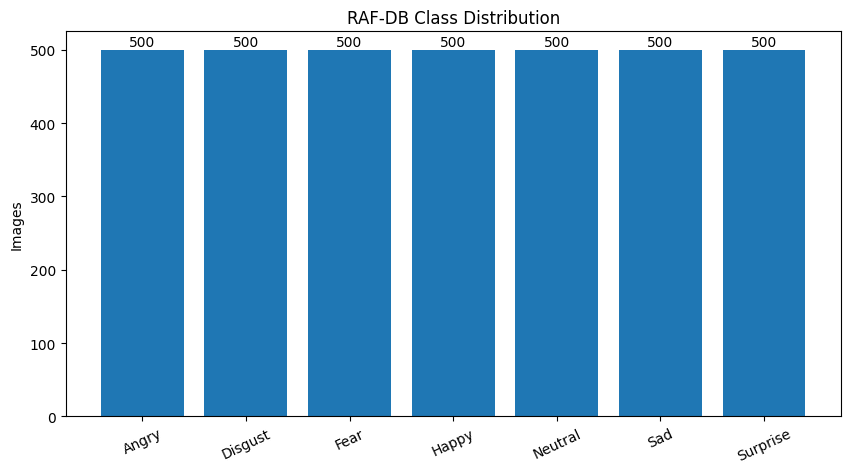

In [8]:
class_counts = []

for i in range(len(emotion_names)):

    class_counts.append(
        (labels==i).sum()
    )

plt.figure(figsize=(10,5))

bars = plt.bar(
    emotion_names,
    class_counts
)

plt.title(
    "RAF-DB Class Distribution"
)

plt.ylabel("Images")

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+5,
        int(bar.get_height()),
        ha='center'
    )

plt.xticks(rotation=25)

plt.show()

In [9]:
X_hog = []

for img in data:

    feature = hog(
        img,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2)
    )

    X_hog.append(feature)

X_hog = np.array(X_hog)

print("HOG Shape:", X_hog.shape)

HOG Shape: (3500, 8100)


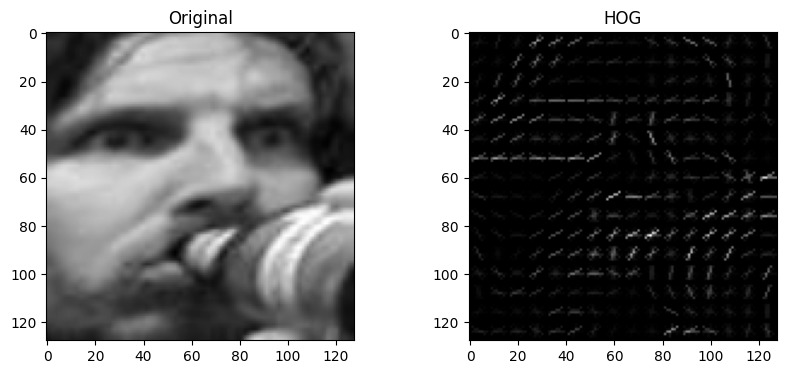

In [10]:
sample = data[0]

features, hog_image = hog(
    sample,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True
)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(sample,cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(hog_image,cmap='gray')
plt.title("HOG")

plt.show()

In [11]:
mobilenet = MobileNetV2(
    weights='imagenet',
    include_top=False,
    pooling='avg'
)

vgg = VGG16(
    weights='imagenet',
    include_top=False,
    pooling='avg'
)

print("Models Loaded")

/tmp/ipykernel_16/3425155617.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNetV2(
2026-06-18 08:04:17.340617: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Models Loaded


In [12]:
def extract_mobilenet_features(
    images,
    model
):

    features = []

    for img in images:

        img = cv2.resize(
            img,
            (224,224)
        )

        img = cv2.cvtColor(
            img,
            cv2.COLOR_GRAY2RGB
        )

        img = preprocess_input(img)

        img = np.expand_dims(
            img,
            axis=0
        )

        feat = model.predict(
            img,
            verbose=0
        )

        features.append(
            feat.flatten()
        )

    return np.array(features)

In [13]:
def extract_vgg_features(
    images,
    model
):

    features = []

    for img in images:

        img = cv2.resize(
            img,
            (224,224)
        )

        img = cv2.cvtColor(
            img,
            cv2.COLOR_GRAY2RGB
        )

        img = vgg_preprocess(img)

        img = np.expand_dims(
            img,
            axis=0
        )

        feat = model.predict(
            img,
            verbose=0
        )

        features.append(
            feat.flatten()
        )

    return np.array(features)

In [14]:
X_cnn = extract_mobilenet_features(
    data,
    mobilenet
)

print("MobileNet Shape:", X_cnn.shape)

MobileNet Shape: (3500, 1280)


In [15]:
X_vgg = extract_vgg_features(
    data,
    vgg
)

print("VGG Shape:", X_vgg.shape)

VGG Shape: (3500, 512)


In [16]:
X_hybrid = np.concatenate(
    [X_cnn, X_vgg],
    axis=1
)

X_hog_cnn = np.concatenate(
    [X_hog, X_cnn],
    axis=1
)

X_hog_vgg = np.concatenate(
    [X_hog, X_vgg],
    axis=1
)

X_final = np.concatenate(
    [X_hog, X_cnn, X_vgg],
    axis=1
)

print("Hybrid Shape:", X_hybrid.shape)
print("HOG+CNN:", X_hog_cnn.shape)
print("HOG+VGG:", X_hog_vgg.shape)
print("All Features:", X_final.shape)

Hybrid Shape: (3500, 1792)
HOG+CNN: (3500, 9380)
HOG+VGG: (3500, 8612)
All Features: (3500, 9892)


In [17]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_predict

def run_model_cv(X, name):

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='linear'))
    ])

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    y_pred = cross_val_predict(
        model,
        X,
        labels,
        cv=skf,
        n_jobs=-1
    )

    acc = accuracy_score(
        labels,
        y_pred
    )

    print(f"\n{name} Accuracy: {acc:.4f}")

    report = classification_report(
        labels,
        y_pred,
        target_names=emotion_names,
        output_dict=True
    )

    cm = confusion_matrix(
        labels,
        y_pred
    )

    return {
        'name': name,
        'accuracy': acc,
        'report': report,
        'cm': cm,
        'y_pred': y_pred
    }
    

In [18]:
results = []

results.append(
    run_model_cv(X_hog, "HOG")
)

results.append(
    run_model_cv(X_cnn, "MobileNet")
)

results.append(
    run_model_cv(X_vgg, "VGG16")
)

results.append(
    run_model_cv(
        X_hybrid,
        "VGG + MobileNet"
    )
)

results.append(
    run_model_cv(
        X_hog_vgg,
        "HOG + VGG"
    )
)

results.append(
    run_model_cv(
        X_hog_cnn,
        "HOG + MobileNet"
    )
)

results.append(
    run_model_cv(
        X_final,
        "All Features"
    )
)


HOG Accuracy: 0.6083

MobileNet Accuracy: 0.5014

VGG16 Accuracy: 0.4857

VGG + MobileNet Accuracy: 0.5574

HOG + VGG Accuracy: 0.6363

HOG + MobileNet Accuracy: 0.6411

All Features Accuracy: 0.6566


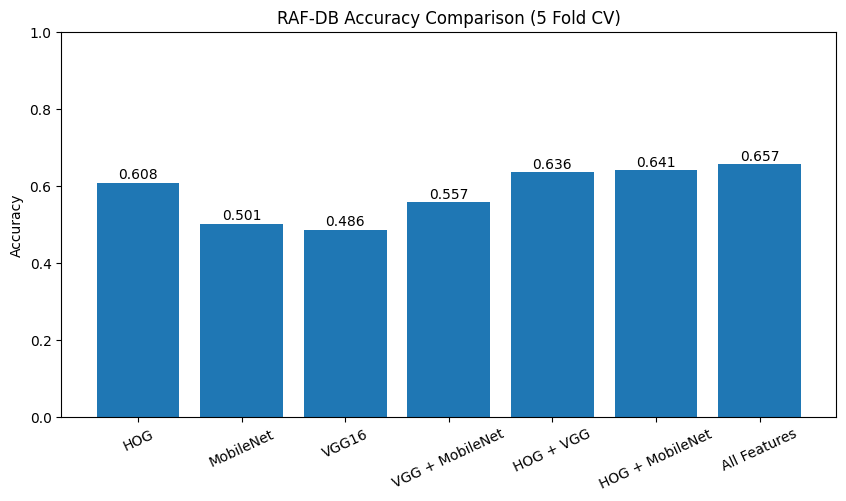

In [19]:
model_names = []
accuracies = []

for res in results:

    model_names.append(
        res['name']
    )

    accuracies.append(
        res['accuracy']
    )

plt.figure(figsize=(10,5))

bars = plt.bar(
    model_names,
    accuracies
)

plt.ylim(0,1)

plt.title(
    "RAF-DB Accuracy Comparison (5 Fold CV)"
)

plt.ylabel("Accuracy")

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        yval+0.01,
        f"{yval:.3f}",
        ha='center'
    )

plt.xticks(rotation=25)

plt.show()

In [20]:
accuracy_df = pd.DataFrame({

    'Model': model_names,
    'Accuracy': accuracies

})

accuracy_df.sort_values(
    by='Accuracy',
    ascending=False,
    inplace=True
)

accuracy_df

,Model,Accuracy
6,All Features,0.656571
5,HOG + MobileNet,0.641143
4,HOG + VGG,0.636286
0,HOG,0.608286
3,VGG + MobileNet,0.557429
1,MobileNet,0.501429
2,VGG16,0.485714


In [21]:
emotion_f1 = pd.DataFrame()

for res in results:

    scores = []

    for emotion in emotion_names:

        scores.append(
            res['report'][emotion]['f1-score']
        )

    emotion_f1[
        res['name']
    ] = scores

emotion_f1.index = emotion_names

emotion_f1

,HOG,MobileNet,VGG16,VGG + MobileNet,HOG + VGG,HOG + MobileNet,All Features
Angry,0.649106,0.574839,0.527928,0.602455,0.684461,0.690522,0.700193
Disgust,0.473581,0.402634,0.383135,0.472015,0.488625,0.518304,0.533981
Fear,0.684366,0.644724,0.640701,0.697406,0.703340,0.708210,0.731707
Happy,0.755741,0.565574,0.565762,0.655670,0.768432,0.798354,0.802073
Neutral,0.529007,0.413650,0.397104,0.446541,0.568116,0.552400,0.565049
Sad,0.508439,0.371490,0.335171,0.416931,0.556375,0.541623,0.566316
Surprise,0.660513,0.522199,0.540426,0.600626,0.687179,0.683077,0.701863


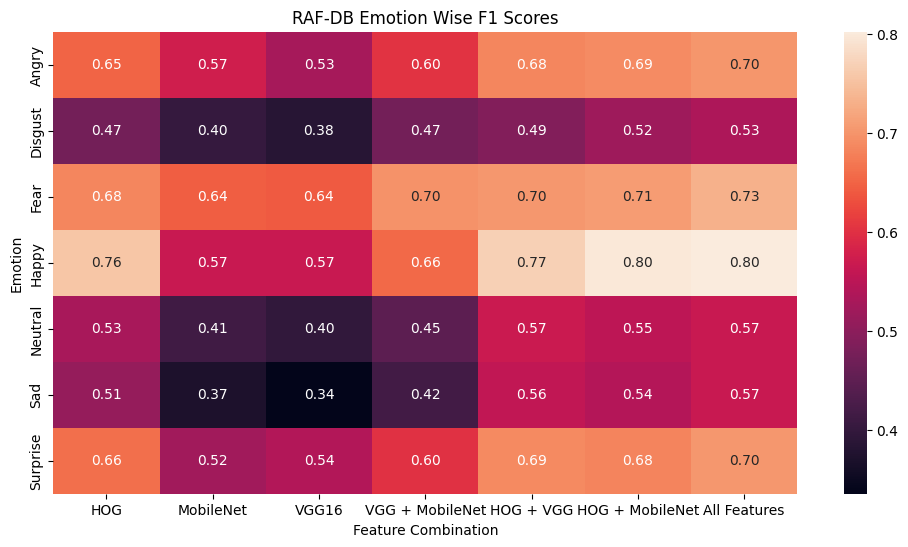

In [22]:
plt.figure(figsize=(12,6))

sns.heatmap(
    emotion_f1,
    annot=True,
    fmt='.2f'
)

plt.title(
    "RAF-DB Emotion Wise F1 Scores"
)

plt.xlabel(
    "Feature Combination"
)

plt.ylabel(
    "Emotion"
)

plt.show()

In [23]:
print(
    "\n=== BEST FEATURE SET FOR EACH EMOTION ===\n"
)

for emotion in emotion_names:

    best_model = (
        emotion_f1.loc[emotion]
        .idxmax()
    )

    best_score = (
        emotion_f1.loc[emotion]
        .max()
    )

    print(
        f"{emotion}: "
        f"{best_model} "
        f"({best_score:.3f})"
    )


=== BEST FEATURE SET FOR EACH EMOTION ===

Angry: All Features (0.700)
Disgust: All Features (0.534)
Fear: All Features (0.732)
Happy: All Features (0.802)
Neutral: HOG + VGG (0.568)
Sad: All Features (0.566)
Surprise: All Features (0.702)


In [24]:
expert_df = pd.DataFrame(
    columns=[
        'Emotion',
        'Best Expert',
        'F1 Score'
    ]
)

for emotion in emotion_names:

    best_model = (
        emotion_f1.loc[emotion]
        .idxmax()
    )

    best_score = (
        emotion_f1.loc[emotion]
        .max()
    )

    expert_df.loc[
        len(expert_df)
    ] = [
        emotion,
        best_model,
        round(best_score,3)
    ]

expert_df

,Emotion,Best Expert,F1 Score
0,Angry,All Features,0.700
1,Disgust,All Features,0.534
2,Fear,All Features,0.732
3,Happy,All Features,0.802
4,Neutral,HOG + VGG,0.568
5,Sad,All Features,0.566
6,Surprise,All Features,0.702


In [25]:
summary = []

for res in results:

    summary.append([

        res['name'],

        round(res['accuracy'],4),

        round(
            res['report']['macro avg']['precision'],
            4
        ),

        round(
            res['report']['macro avg']['recall'],
            4
        ),

        round(
            res['report']['macro avg']['f1-score'],
            4
        )
    ])

summary_df = pd.DataFrame(

    summary,

    columns=[

        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

summary_df.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
6,All Features,0.6566,0.6597,0.6566,0.6573
5,HOG + MobileNet,0.6411,0.6437,0.6411,0.6418
4,HOG + VGG,0.6363,0.6386,0.6363,0.6366
0,HOG,0.6083,0.6109,0.6083,0.6087
3,VGG + MobileNet,0.5574,0.5571,0.5574,0.5559
1,MobileNet,0.5014,0.5003,0.5014,0.4993
2,VGG16,0.4857,0.4874,0.4857,0.4843


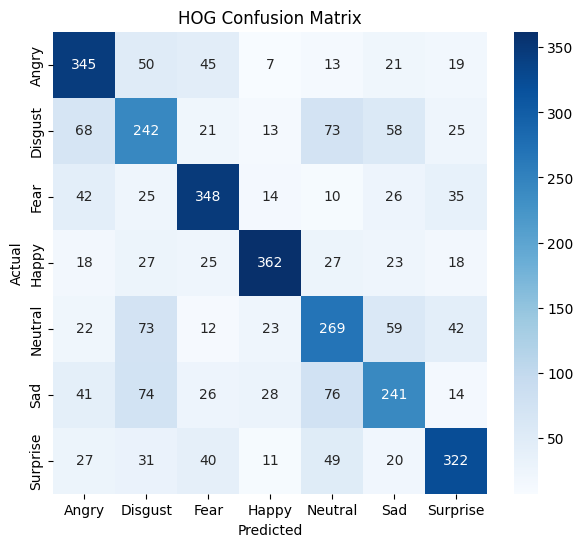

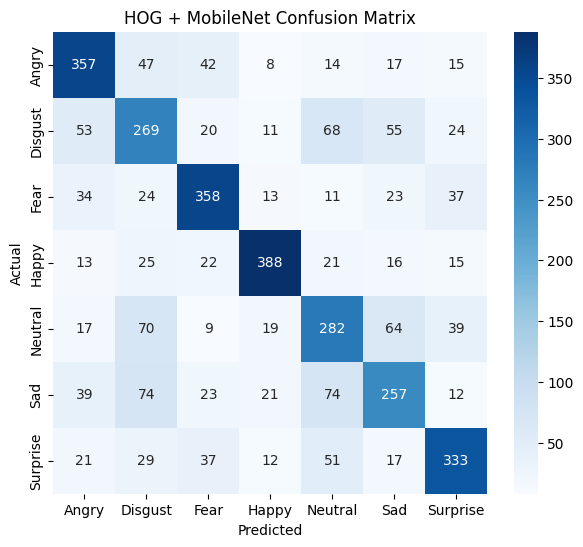

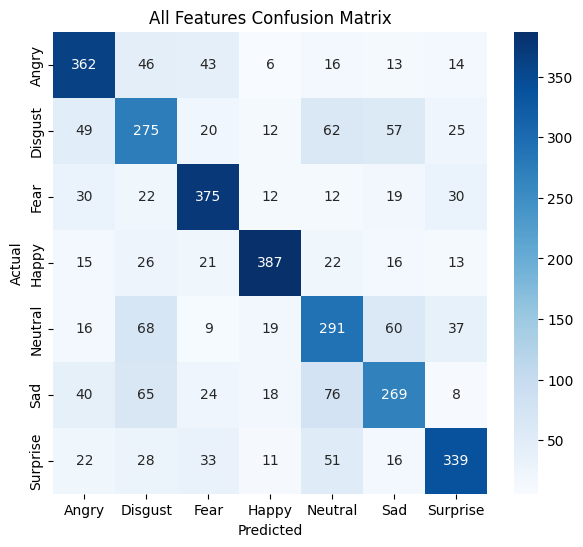

In [26]:
important_models = [

    "HOG",
    "HOG + MobileNet",
    "All Features"
]

for res in results:

    if res['name'] in important_models:

        plt.figure(figsize=(7,6))

        sns.heatmap(

            res['cm'],

            annot=True,

            fmt='d',

            cmap='Blues',

            xticklabels=emotion_names,

            yticklabels=emotion_names

        )

        plt.title(
            f"{res['name']} Confusion Matrix"
        )

        plt.xlabel("Predicted")
        plt.ylabel("Actual")

        plt.show()

In [27]:
per_emotion_acc = pd.DataFrame()

for res in results:

    cm = res['cm']

    emotion_acc = []

    for i in range(len(emotion_names)):

        acc = cm[i,i] / cm[i].sum()

        emotion_acc.append(acc)

    per_emotion_acc[res['name']] = emotion_acc

per_emotion_acc.index = emotion_names

per_emotion_acc

,HOG,MobileNet,VGG16,VGG + MobileNet,HOG + VGG,HOG + MobileNet,All Features
Angry,0.690,0.626,0.586,0.638,0.718,0.714,0.724
Disgust,0.484,0.428,0.418,0.506,0.494,0.538,0.550
Fear,0.696,0.666,0.658,0.726,0.716,0.716,0.750
Happy,0.724,0.552,0.542,0.636,0.740,0.776,0.774
Neutral,0.538,0.400,0.384,0.426,0.588,0.564,0.582
Sad,0.482,0.344,0.304,0.394,0.528,0.514,0.538
Surprise,0.644,0.494,0.508,0.576,0.670,0.666,0.678


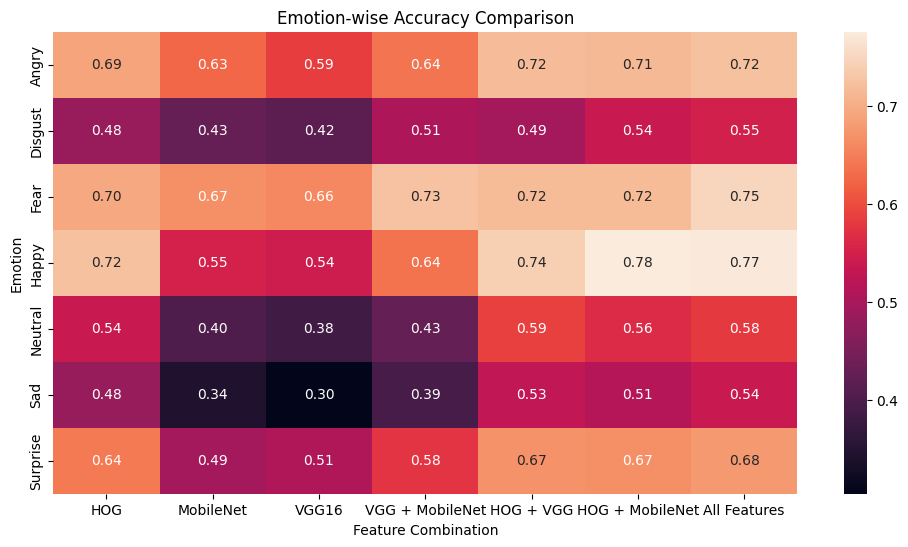

In [28]:
plt.figure(figsize=(12,6))

sns.heatmap(
    per_emotion_acc,
    annot=True,
    fmt='.2f'
)

plt.title(
    "Emotion-wise Accuracy Comparison"
)

plt.xlabel(
    "Feature Combination"
)

plt.ylabel(
    "Emotion"
)

plt.show()

In [29]:
accuracy_expert_df = pd.DataFrame(
    columns=[
        "Emotion",
        "Best Expert",
        "Accuracy"
    ]
)

for emotion in emotion_names:

    best_model = (
        per_emotion_acc.loc[emotion]
        .idxmax()
    )

    best_acc = (
        per_emotion_acc.loc[emotion]
        .max()
    )

    accuracy_expert_df.loc[
        len(accuracy_expert_df)
    ] = [
        emotion,
        best_model,
        round(best_acc,3)
    ]

accuracy_expert_df

,Emotion,Best Expert,Accuracy
0,Angry,All Features,0.724
1,Disgust,All Features,0.550
2,Fear,All Features,0.750
3,Happy,HOG + MobileNet,0.776
4,Neutral,HOG + VGG,0.588
5,Sad,All Features,0.538
6,Surprise,All Features,0.678
